In [1]:
import pandas as pd
import numpy as np

In [4]:
# Load the dataset
df=pd.read_csv(r"C:\Users\shrey\Downloads\agriculture_yield_dataset.csv")
df

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
...,...,...,...,...,...,...,...,...
1495,473.8,32.3,65.0,3.6,5.8,Cotton,Sandy,3.28
1496,825.9,18.4,200.8,9.9,6.7,Cotton,Sandy,5.16
1497,329.3,23.3,90.3,7.7,7.0,Soybean,Sandy,3.60
1498,801.7,28.6,204.1,3.4,6.9,Rice,Sandy,5.03


In [6]:
# How many rows and columns are present? 
df.shape

(1500, 8)

In [7]:
# What are the names of all columns?  
df.columns

Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')

In [9]:
df.head(10)

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


In [10]:
# Check the data type of each column.
df.dtypes

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

In [14]:
#  Identify whether any missing values are present.  
df.isnull().sum()

rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

In [15]:
# If missing values exist, mention the affected columns. 
# Count missing values in each column
missing_values = df.isnull().sum()

# Select columns with at least one missing value
affected_columns = missing_values[missing_values > 0]

if len(affected_columns) > 0:
    print("Columns with missing values:")
    print(affected_columns)
else:
    print("No missing values found.")

No missing values found.


In [18]:
# Generate summary statistics for all numerical features 
df.describe()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


Which feature has the highest mean value?  
Rainfall_mm has highest mean
 Which feature has the highest standard deviation? 
 Rainfall_mm has highest standard deviation

array([[<Axes: title={'center': 'rainfall_mm'}>,
        <Axes: title={'center': 'temperature_c'}>],
       [<Axes: title={'center': 'fertilizer_kg'}>,
        <Axes: title={'center': 'yield_ton_per_hectare'}>]], dtype=object)

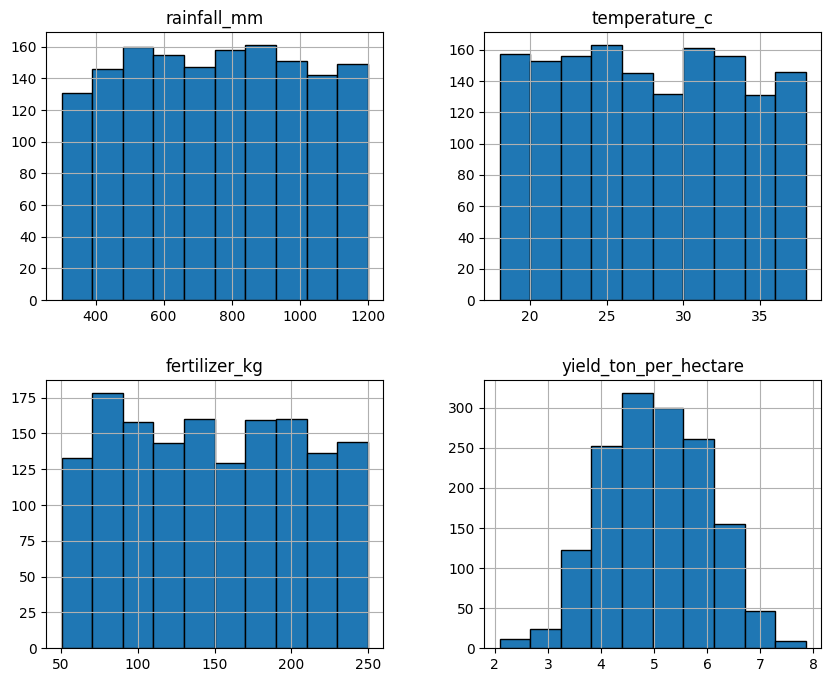

In [20]:
# Create histograms for:  rainfall_mm   temperature_c   fertilizer_kg   yield_ton_per_hectare  Write 2–3 observations from each histogram. 
import matplotlib.pyplot as plt
df[['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'yield_ton_per_hectare']].hist(
    bins=10, figsize=(10,8), edgecolor='black'
)

rainfall_mm
Most observations are concentrated around 900 mm.

There are several extreme rainfall values.
temperature_c
Temperatures mainly range from 15 °C to40 °C.
The distribution appears evenly distributed.
There are no noticeable outliers.
fertilizer_kg
Most farms use between 50 and 100 kg of fertilizer.
The histogram is symmetric.

yield_ton_per_hectare
Crop yields are concentrated around 4.5 tons/hectare.
The distribution isnormal.


crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


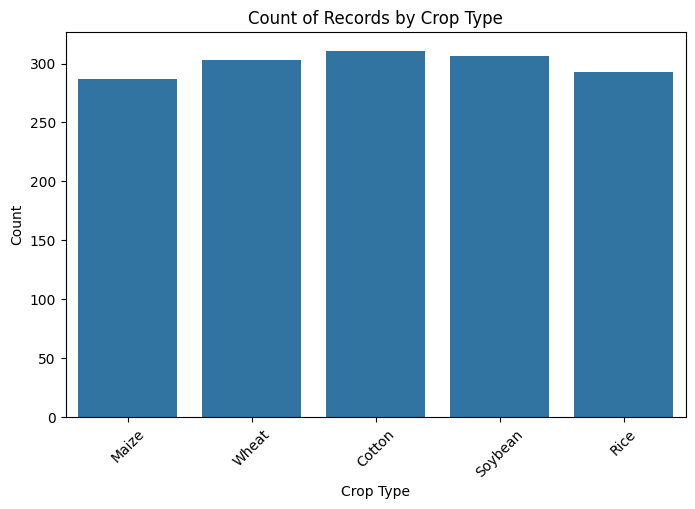

The most frequent crop is Cotton with 311 records.


In [23]:
# Crop Type Analysis  Find the number of records for each crop type.   Create a count plot (bar chart) for crop_type.   Which crop appears most frequently? 
# Count the number of records for each crop type
crop_counts = df['crop_type'].value_counts()

print(crop_counts)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x='crop_type', data=df)
plt.title('Count of Records by Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()
most_frequent_crop = df['crop_type'].value_counts().idxmax()
count = df['crop_type'].value_counts().max()

print(f"The most frequent crop is {most_frequent_crop} with {count} records.")

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


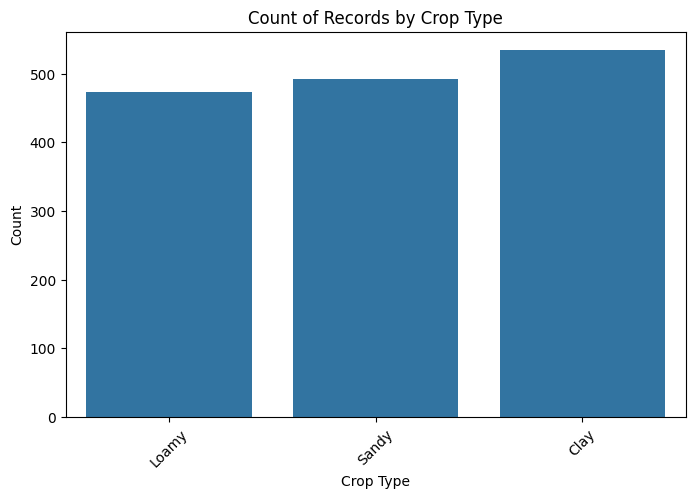

The most frequent soil is Clay with 534 records.


In [25]:
# Find the frequency of each soil type.   Create a count plot for soil_type.   Which soil type is most common? 
crop_counts = df['soil_type'].value_counts()

print(crop_counts)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x='soil_type', data=df)
plt.title('Count of Records by Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()
most_frequent_soil = df['soil_type'].value_counts().idxmax()
count = df['soil_type'].value_counts().max()

print(f"The most frequent soil is {most_frequent_soil} with {count} records.")

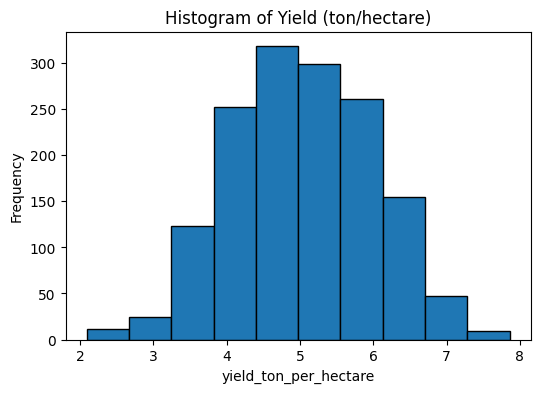

In [26]:
# Create a histogram of yield_ton_per_hectare. Answer:  Is the distribution approximately normal?   Are there any noticeable outliers?
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df['yield_ton_per_hectare'], bins=10, edgecolor='black')
plt.title('Histogram of Yield (ton/hectare)')
plt.xlabel('yield_ton_per_hectare')
plt.ylabel('Frequency')
plt.show()

Is the distribution approximately normal?

It is approximately normal.

Are there any noticeable outliers?

There are noticeable outliers.

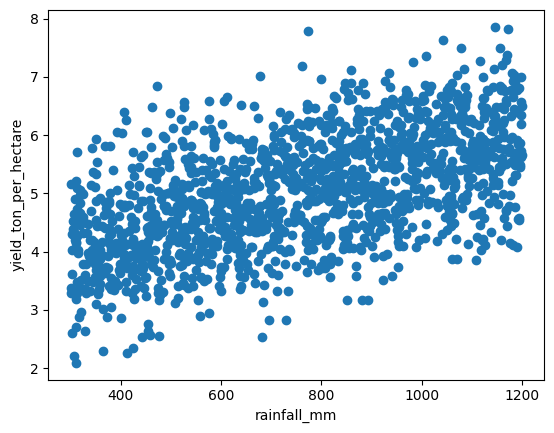

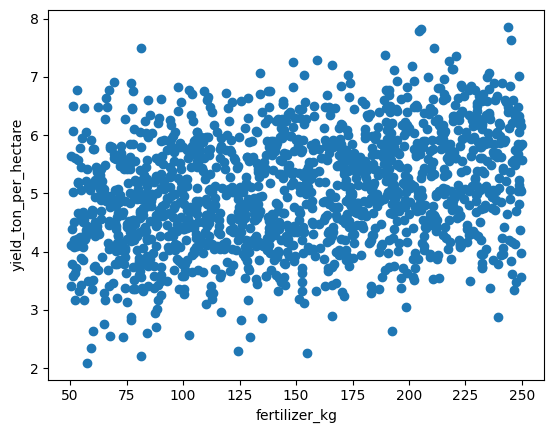

In [30]:
# Create scatter plots of: 1. rainfall_mm vs yield_ton_per_hectare  2. fertilizer_kg vs yield_ton_per_hectare
import matplotlib.pyplot as plt

# rainfall_mm vs yield
plt.scatter(df['rainfall_mm'], df['yield_ton_per_hectare'])
plt.xlabel('rainfall_mm')
plt.ylabel('yield_ton_per_hectare')
plt.show()

# fertilizer_kg vs yield
plt.scatter(df['fertilizer_kg'], df['yield_ton_per_hectare'])
plt.xlabel('fertilizer_kg')
plt.ylabel('yield_ton_per_hectare')
plt.show()

Which feature appears to have a stronger relationship with yield? 
Rainfall_mm have stroonger relationship

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

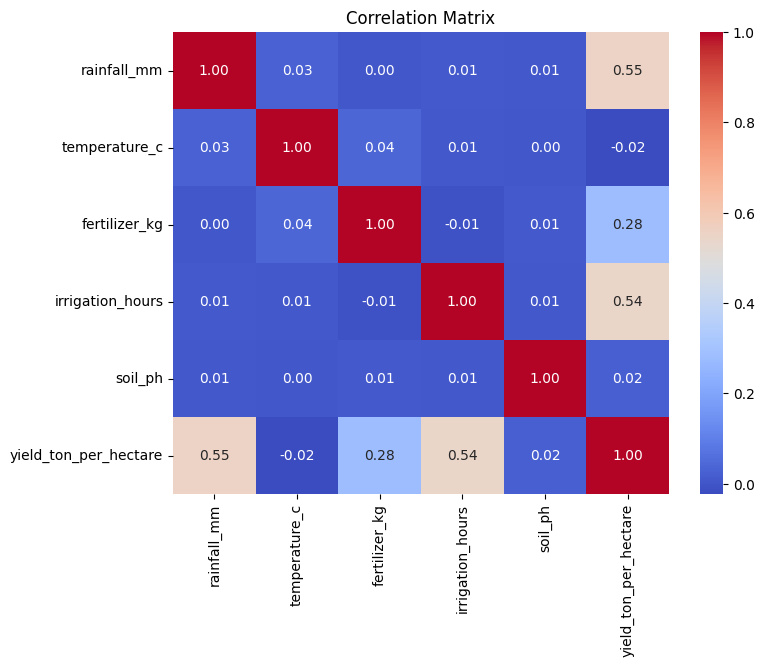

rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64


In [31]:
# Correlation Analysis  Generate a correlation matrix for numerical features.   Create a heatmap.   Identify the top three features most correlated with crop yield. 
# Correlation matrix
corr_matrix = df.corr(numeric_only=True)

print(corr_matrix)
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()
# Correlation with crop yield
yield_corr = corr_matrix['yield_ton_per_hectare']

# Top 3 features (excluding yield itself)
top3 = yield_corr.drop('yield_ton_per_hectare').abs().sort_values(ascending=False).head(3)

print(top3)

In [32]:
# Calculate the average yield for:  Each crop type   Each soil type  Which crop and soil type have the highest average yield? 
avg_yield_crop = df.groupby('crop_type')['yield_ton_per_hectare'].mean()

print(avg_yield_crop)
avg_yield_soil = df.groupby('soil_type')['yield_ton_per_hectare'].mean()

print(avg_yield_soil)
highest_crop = avg_yield_crop.idxmax()
highest_crop_yield = avg_yield_crop.max()

print("Crop with highest average yield:", highest_crop)
print("Average yield:", highest_crop_yield)
highest_soil = avg_yield_soil.idxmax()
highest_soil_yield = avg_yield_soil.max()

print("Soil type with highest average yield:", highest_soil)
print("Average yield:", highest_soil_yield)

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64
Crop with highest average yield: Rice
Average yield: 5.494744027303755
Soil type with highest average yield: Loamy
Average yield: 5.366518987341772


In [33]:
# The dataset contains categorical variables.  Identify the categorical columns.   Convert them into numerical form using One-Hot Encoding.   Display the first five rows of the transformed dataset. 
# Display categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Categorical columns:")
print(categorical_cols)
# One-Hot Encode categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols)

# Display column names of transformed dataset
print(df_encoded.columns)
# Display first five rows
print(df_encoded.head())

Categorical columns:
Index(['crop_type', 'soil_type'], dtype='object')
Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'yield_ton_per_hectare', 'crop_type_Cotton',
       'crop_type_Maize', 'crop_type_Rice', 'crop_type_Soybean',
       'crop_type_Wheat', 'soil_type_Clay', 'soil_type_Loamy',
       'soil_type_Sandy'],
      dtype='object')
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Cotton  crop_type_Maize  crop_type_Rice  \
0                   5.92             False             True           False   
1   

In [34]:
# Separate:  Input features (X)   Target variable (y)  Specify which column is being used as the target variable. 
# Specify the target variable
target_column = 'yield_ton_per_hectare'

# Separate input features (X) and target variable (y)
X = df_encoded.drop(columns=[target_column])
y = df_encoded[target_column]

# Display the results
print("Target variable:", target_column)
print("Input features shape:", X.shape)
print("Target variable shape:", y.shape)

Target variable: yield_ton_per_hectare
Input features shape: (1500, 13)
Target variable shape: (1500,)


In [35]:
# Train-Test Split Split the dataset into:  80% Training Data   20% Testing Data  Display the shape of:  X_train   X_test   y_train   y_tes
from sklearn.model_selection import train_test_split

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Display the shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1200, 13)
X_test shape: (300, 13)
y_train shape: (1200,)
y_test shape: (300,)


In [36]:
# Train a Linear Regression model.   Display the model coefficients and intercept.   Which feature has the highest positive coefficient? 
from sklearn.linear_model import LinearRegression

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)
# Display coefficients and intercept
print("Intercept:", model.intercept_)

coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

print(coefficients)
# Feature with the highest positive coefficient
max_coef_index = model.coef_.argmax()

highest_feature = X_train.columns[max_coef_index]
highest_coef = model.coef_[max_coef_index]

print("Feature with highest positive coefficient:", highest_feature)
print("Coefficient value:", highest_coef)

Intercept: 1.9111026182800752
              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5    crop_type_Cotton    -0.386623
6     crop_type_Maize    -0.147693
7      crop_type_Rice     0.477369
8   crop_type_Soybean     0.095096
9     crop_type_Wheat    -0.038149
10     soil_type_Clay     0.062653
11    soil_type_Loamy     0.365627
12    soil_type_Sandy    -0.428280
Feature with highest positive coefficient: crop_type_Rice
Coefficient value: 0.4773694124782616
